In [1]:
import pandas as pd, numpy as np

%load_ext autoreload
%autoreload 2

!date

Sat Sep  5 13:46:04 PDT 2026


# HCES Data Extraction
We have HCES data to inform rice consumption (of PSD-distributed and non-PSD rice) by women and birthing people of 
reproductive age (WBPRA) and U5 children in India. We need to do further investigation as to what percentage of PSD-
distributed rice has been fortified with iron and folate.

HCES data and documentation is saved on Sharepoint here: https://uwnetid.sharepoint.com/:f:/r/sites/ihme_simulation_science_team/Shared%20Documents/Research/LSFF/07_Data/HCES_22_data_files?csf=1&web=1&e=wmxQSD

Item codes for 'Rice' include: 101, 102, and 061. See Section 5.1 of the above documentation for more context.
- Item code 101 signifies rice procured through PDS, using ration card.
- Item code 061 signifies rice procured through PDS, free of charge.
- Item code 102 signifies rice procured/consumed from other sources. (NOTE: Presumably this is unfortified rice.)

We also will need to approximate DHS wealth quintiles in the HCES data, by using similar variables as is used by the DHS to 
calculate wealth quintiles in India (see DHS wealth quintile documentation here: 
https://dhsprogram.com/programming/wealth%20index/India%20DHS%202015-16/India%202015-16%20sps.txt)

In this notebook, we extract the raw data from the HCES website and do some initial processing in order to create files 
that we can further tabulate based on our project needs in a later step. For now, we process these raw data into dataframes 
that have a row for each household/individual with the following columns:
- Whether or not rice was consumed (binary variable - this will be used to calculate coverage percentages later)
- Amount of PDS rice consumed (grams per day - currently in raw HCES, *I think* this is in kg per 2 weeks; this will be used to calculate fortified rice consumption amount) 
- Amount of non-PDS rice consumed (grams per day - currently in raw HCES, *I think* this is in kg per 2 weeks; this will be used to calculate unfortified rice consumption amount) 
- Wealth composite score/quintile 
- Sex/gender (will be used to calculate WBPRA)
- Age (will be used to tabulate age groups)

**2023-24 update:** this notebook now reads the HCES 2023-24 unit-level data. The
acquisition (GHDx NID 583328, help desk ticket DSS-11170) is Nesstar-only; the readable
tab exports live in
`/snfs1/Project/simulation_science/IND_HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES_2023_2024/`
(see the README.txt there for provenance and verified row counts). Unlike the 2022-23
fixed-width library files, these are tab-delimited with no header row, and the 38-byte
common ID arrives split across the first 16 columns. Field definitions:
`IND_HCES_2023_2024_LAYOUT_Y2025M05D22.XLSX` in the data library's `2023_2024` folder.
Item codes for rice are unchanged (101 PDS ration, 061 PDS free, 102 other) -- but note
PMGKAY made PDS grain free from January 2023, so the consuming-household mix shifts
heavily from 101 to 061 relative to 2022-23.


## Load data

In [2]:
data_dir = "/snfs1/Project/simulation_science/IND_HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES_2023_2024"

# The 16 columns the tab exports split the 38-byte fixed-width common ID into, with the
# fixed-width field widths used to reassemble it.
COMMON_ID_COLUMNS = [
    "survey_name",
    "year",
    "fsu_serial_no",
    "sector",
    "state",
    "nss_region",
    "district",
    "stratum",
    "sub_stratum",
    "panel",
    "sub_sample",
    "fod_sub_region",
    "sample_su_no",
    "sample_sub_division_no",
    "second_stage_stratum_no",
    "sample_household_no",
]
COMMON_ID_WIDTHS = [4, 4, 5, 1, 2, 3, 2, 2, 2, 2, 1, 4, 2, 1, 1, 2]

# Row counts from the MoSPI manifest in the package readme. A mismatch means a truncated
# Nesstar export -- they fail silently, and it happened during extraction, so always check.
MANIFEST_ROW_COUNTS = {
    1: 261_953,
    2: 1_107_221,
    3: 261_953,
    5: 12_754_437,
    7: 261_953,
    11: 261_953,
}


def build_common_id(df):
    """Reassemble the 38-character common ID of the 2022-23 fixed-width layout."""
    common_id = ""
    for col, width in zip(COMMON_ID_COLUMNS, COMMON_ID_WIDTHS):
        fill_val = "0"
        side = "left"
        if col in ("sample_su_no", "sample_sub_division_no", "panel"):
            # No clue. (Same convention as the 2022-23 extraction.)
            fill_val = " "
            side = "right"
        values = df[col].fillna(fill_val).str.pad(width, fillchar=fill_val, side=side)
        assert (values.str.len() == width).all()
        common_id = common_id + values
    return common_id


def read_hces_level(level_no, names, keep_id_fields=False, row_filter=None):
    """Read one 2023-24 tab export: no header, common ID split across the first 16 columns."""
    path = f"{data_dir}/IND_HCES_2023_2024_LVL_{level_no:02d}_TAB_Y2026M09D03.TXT"
    kwargs = dict(
        sep="\t",
        header=None,
        names=COMMON_ID_COLUMNS + names,
        # Keep the ID fields as text: they only exist to rebuild the common ID, and
        # numeric parsing would corrupt it (leading zeros, blanks becoming floats).
        dtype={c: str for c in COMMON_ID_COLUMNS},
    )
    if row_filter is None:
        df = pd.read_csv(path, **kwargs)
        n_rows = len(df)
    else:
        # Level 5 is 12.7M rows; filter each chunk before assembling to keep memory sane.
        chunks, n_rows = [], 0
        for chunk in pd.read_csv(path, chunksize=2_000_000, **kwargs):
            n_rows += len(chunk)
            chunks.append(row_filter(chunk))
        df = pd.concat(chunks, ignore_index=True)
    assert n_rows == MANIFEST_ROW_COUNTS[level_no], (level_no, n_rows)
    df.insert(0, "common_id", build_common_id(df))
    if not keep_id_fields:
        df = df.drop(columns=COMMON_ID_COLUMNS)
    return df


In [3]:
level_1 = read_hces_level(
    1,
    names=[
        "questionnaire_no",
        "level",
        "survey_code",
        "reason_for_substitution_code",
        "multiplier",
    ],
    keep_id_fields=True,
)
level_1


,common_id,survey_name,year,fsu_serial_no,sector,state,nss_region,district,stratum,sub_stratum,...,fod_sub_region,sample_su_no,sample_sub_division_no,second_stage_stratum_no,sample_household_no,questionnaire_no,level,survey_code,reason_for_substitution_code,multiplier
0,HCES2024466671010120613012 201103 201,HCES,2024,46667,1,01,012,06,13,01,...,0110,3,NaN,2,01,H,1,1,NaN,16669
1,HCES2024466671010120613012 201103 301,HCES,2024,46667,1,01,012,06,13,01,...,0110,3,NaN,3,01,H,1,1,NaN,24840
2,HCES2024466671010120613012 201103 302,HCES,2024,46667,1,01,012,06,13,01,...,0110,3,NaN,3,02,H,1,1,NaN,24840
3,HCES2024466671010120613012 201103 303,HCES,2024,46667,1,01,012,06,13,01,...,0110,3,NaN,3,03,H,1,1,NaN,24840
4,HCES2024466671010120613012 201103 304,HCES,2024,46667,1,01,012,06,13,01,...,0110,3,NaN,3,04,H,1,1,NaN,24840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261948,HCES2024432771101011923356 2101116 314,HCES,2024,43277,1,10,101,19,23,35,...,1011,16,NaN,3,14,H,1,1,NaN,157235
261949,HCES2024432771101011923356 2101116 315,HCES,2024,43277,1,10,101,19,23,35,...,1011,16,NaN,3,15,H,1,1,NaN,157235
261950,HCES2024432771101011923356 2101116 316,HCES,2024,43277,1,10,101,19,23,35,...,1011,16,NaN,3,16,H,1,1,NaN,157235
261951,HCES2024432771101011923356 2101116 317,HCES,2024,43277,1,10,101,19,23,35,...,1011,16,NaN,3,17,H,1,1,NaN,157235


In [4]:
assert level_1.common_id.is_unique
level_1["common_id"]


0         HCES2024466671010120613012 201103  201
1         HCES2024466671010120613012 201103  301
2         HCES2024466671010120613012 201103  302
3         HCES2024466671010120613012 201103  303
4         HCES2024466671010120613012 201103  304
                           ...                  
261948    HCES2024432771101011923356 2101116 314
261949    HCES2024432771101011923356 2101116 315
261950    HCES2024432771101011923356 2101116 316
261951    HCES2024432771101011923356 2101116 317
261952    HCES2024432771101011923356 2101116 318
Name: common_id, Length: 261953, dtype: object

In [5]:
# The 2023-24 HCQ dropped the dwelling building-material, drinking-water and latrine
# questions that 2022-23 asked (they fed the wealth index -- see the note in the wealth
# section), and added ration-card type and PMGKY benefit.
level_3 = read_hces_level(
    3,
    names=[
        "questionnaire_no",
        "level",
        "hh_size",
        "household_member_economic_activity_last_365_days",
        "nco_2015_code",
        "nic_2008_code",
        "max_income_source_last_365_days",
        "major_income_source_self_employment_sector",
        "major_income_regular_wage_sector",
        "major_income_casual_labour_sector",
        "household_type",
        "head_religion",
        "head_social_group",
        "land_ownership",
        "land_type",
        "total_owned_land_area",
        "has_dwelling",
        "dwelling_unit_type",
        "cooking_energy_source",
        "lighting_energy_source",
        "ration_card_type",
        "rural_rent_rate_availability",
        "pmgky_benefit",
        "multiplier",
    ],
)
level_3


,common_id,questionnaire_no,level,hh_size,household_member_economic_activity_last_365_days,nco_2015_code,nic_2008_code,max_income_source_last_365_days,major_income_source_self_employment_sector,major_income_regular_wage_sector,...,land_type,total_owned_land_area,has_dwelling,dwelling_unit_type,cooking_energy_source,lighting_energy_source,ration_card_type,rural_rent_rate_availability,pmgky_benefit,multiplier
0,HCES2024466671010120613012 201103 201,H,3,5,1,112.0,46632.0,1.0,2.0,NaN,...,2.0,1.87,1,1.0,2,1,3,2.0,2,16669
1,HCES2024466671010120613012 201103 301,H,3,4,1,233.0,85211.0,2.0,NaN,4.0,...,2.0,0.51,1,1.0,2,1,3,2.0,2,24840
2,HCES2024466671010120613012 201103 302,H,3,5,1,832.0,49219.0,1.0,2.0,NaN,...,2.0,0.52,1,1.0,2,1,2,2.0,1,24840
3,HCES2024466671010120613012 201103 303,H,3,5,1,741.0,35109.0,2.0,NaN,4.0,...,2.0,0.03,1,1.0,2,1,3,2.0,1,24840
4,HCES2024466671010120613012 201103 304,H,3,3,2,NaN,NaN,NaN,NaN,NaN,...,2.0,0.51,1,1.0,2,1,3,2.0,1,24840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261948,HCES2024432771101011923356 2101116 314,H,3,4,1,921.0,1611.0,3.0,NaN,NaN,...,1.0,0.03,1,1.0,9,1,0,2.0,1,157235
261949,HCES2024432771101011923356 2101116 315,H,3,5,1,931.0,41001.0,3.0,NaN,NaN,...,1.0,0.01,1,1.0,2,1,4,2.0,1,157235
261950,HCES2024432771101011923356 2101116 316,H,3,4,1,921.0,1611.0,3.0,NaN,NaN,...,1.0,0.00,1,1.0,9,1,4,2.0,1,157235
261951,HCES2024432771101011923356 2101116 317,H,3,5,1,931.0,41001.0,3.0,NaN,NaN,...,1.0,0.04,1,1.0,2,1,4,2.0,1,157235


In [6]:
assert level_3.common_id.is_unique

In [7]:
level_3.cooking_energy_source

0         2
1         2
2         2
3         2
4         2
         ..
261948    9
261949    2
261950    9
261951    2
261952    1
Name: cooking_energy_source, Length: 261953, dtype: int64

In [8]:
binary_columns = ["land_ownership", "has_dwelling"]

for col in binary_columns:
    level_3[col] = (
        level_3[col]
        .map(
            {
                1: 1.0,
                2: 0.0,
            }
        )
        .astype(float)
    )

In [9]:
level_3.loc[level_3.land_ownership == 0, "total_owned_land_area"] = 0

In [10]:
level_3["dwelling_unit_type"] = level_3.dwelling_unit_type.map(
    {
        1: "owned",
        2: "hired",
        3: "others",
    }
)
level_3["house_ownership"] = (level_3.has_dwelling == 1) & (
    level_3.dwelling_unit_type == "owned"
)

In [11]:
# The 2023-24 HCQ no longer asks about dwelling building materials (2022-23 had
# wall/roof/floor); those wealth-index predictors are unavailable this round.


In [12]:
level_3["cooking_energy_source"] = level_3.cooking_energy_source.map(
    {
        1: "firewood",
        2: "liquid petroleum gas",
        3: "other natural gas",
        4: "dung",
        5: "kerosene",
        6: "coal",
        7: "gobar",
        8: "other biogas",
        10: "charcoal",
        11: "electricity",
        12: "no cooking",
        9: "other",
    }
)

In [13]:
level_3["lighting_energy_source"] = level_3.lighting_energy_source.map(
    {
        1: "electricity",
        2: "kerosene",
        3: "other oil",
        4: "gas",
        5: "candle",
        6: "no lighting",
        9: "other",
    }
)

In [14]:
# The drinking-water-source question was also dropped from the 2023-24 HCQ.


In [15]:
# The latrine questions (access type and latrine type) were also dropped in 2023-24.


<Axes: >

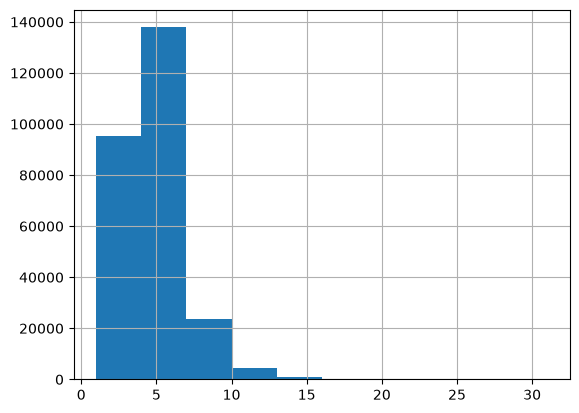

In [16]:
# The fact that there are a couple very large households (e.g. 20+ members) is a little
# surprising - maybe we can investigate to confirm these are some kind of GQ.
level_3.hh_size.hist()

In [17]:
level_7 = read_hces_level(
    7,
    names=[
        "questionnaire_no",
        "level",
        "kerosene",
        "lpg_subsidy",
        "num_lpg_subsidy",
        "free_electricity",
        "attend_education",
        "num_attend_govt_ed",
        "num_attend_priv_ed",
        "free_textbooks",
        "num_free_textbooks",
        "free_stationary",
        "num_free_stationary",
        "free_school_bag",
        "num_free_school_bag",
        "other_free_items",
        "num_other_free_items",
        "fee_waiver",
        "num_fee_waiver",
        "pmjay_beneficiary",
        "num_pmjay_beneficiaries",
        "hospitalization_last_365_days",
        "medical_treatment_benefit",
        "num_medical_benefit",
        "medical_benefit_amount",
        "online_purchase_1",
        "online_purchase_2",
        "online_purchase_3",
        "online_purchase_4",
        "online_purchase_5",
        "multiplier",
    ],
)
level_7


,common_id,questionnaire_no,level,kerosene,lpg_subsidy,num_lpg_subsidy,free_electricity,attend_education,num_attend_govt_ed,num_attend_priv_ed,...,hospitalization_last_365_days,medical_treatment_benefit,num_medical_benefit,medical_benefit_amount,online_purchase_1,online_purchase_2,online_purchase_3,online_purchase_4,online_purchase_5,multiplier
0,HCES2024469561050510621011 205101 301,C,7,2,1,1.0,2,1,0.0,3.0,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57986
1,HCES2024469561050510621011 205101 302,C,7,2,1,2.0,2,1,0.0,2.0,...,2,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,57986
2,HCES2024469561050510621011 205101 303,C,7,2,2,NaN,2,2,NaN,NaN,...,4,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,57986
3,HCES2024469561050510621011 205101 304,C,7,2,1,2.0,2,2,NaN,NaN,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,57986
4,HCES2024469561050510621011 205101 305,C,7,2,1,1.0,2,2,NaN,NaN,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261948,HCES2024432771101011923356 2101116 314,C,7,2,2,NaN,2,2,NaN,NaN,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157235
261949,HCES2024432771101011923356 2101116 315,C,7,2,2,NaN,2,2,NaN,NaN,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157235
261950,HCES2024432771101011923356 2101116 316,C,7,2,2,NaN,2,1,1.0,0.0,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157235
261951,HCES2024432771101011923356 2101116 317,C,7,2,2,NaN,2,2,NaN,NaN,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157235


In [18]:
assert level_7.common_id.is_unique

In [19]:
# 2023-24 dropped the household internet question from the CSQ. Level 2 still asks every
# member about internet use in the last 30 days, so use "any member used the internet"
# as the household indicator. Level 2 is read once here and reused for individual
# consumption below.
household_members_raw = read_hces_level(
    2,
    names=[
        "questionnaire_no",
        "level",
        "person_serial_no",
        "relation_to_head_code",
        "gender",
        "age_years",
        "marital_status_code",
        "highest_education_level_code",
        "total_years_education",
        "internet_use_last_30_days",
        "days_away_from_home_last_30_days",
        "usual_daily_meals",
        "meals_from_school_balwadi_last_30_days",
        "meals_from_employer_last_30_days",
        "meals_others_last_30_days",
        "meals_paid_last_30_days",
        "meals_at_home_last_30_days",
        "member_status_on_revisit",
        "fdq_orig_number",
        "multiplier",
    ],
)

household_internet = (
    (household_members_raw.internet_use_last_30_days == 1)
    .astype(float)
    .groupby(household_members_raw.common_id)
    .max()
    .rename("internet")
)
level_7 = level_7.merge(household_internet, on="common_id", how="left", validate="1:1")


In [20]:
level_11 = read_hces_level(
    11,
    names=[
        "questionnaire_no",
        "level",
        "online_clothing",
        "online_footwear",
        "online_furniture",
        "online_mobile_handset",
        "online_personal_goods",
        "online_recreation_goods",
        "online_cooking_household",
        "online_crockery",
        "online_sports_goods",
        "online_med_equip",
        "online_bedding",
        "free_laptop",
        "num_free_laptop",
        "free_tablet",
        "num_free_tablet",
        "free_mobile",
        "num_free_mobile",
        "free_bicycle",
        "num_free_bicycle",
        "free_motorcycle",
        "num_free_motorcycle",
        "free_clothing",
        "num_free_clothing",
        "free_footwear",
        "num_free_footwear",
        "other_free_items_dgq",
        "num_other_free_items_dgq",
        "tv",
        "radio",
        "laptop",
        "mobile_handset",
        "bicycle",
        "motorcycle",
        "motor_car",
        "trucks",
        "animal_cart",
        "refrigerator",
        "washing_machine",
        "air_conditioner",
        "multichannel_tv_type",
        "multiplier",
    ],
)
level_11


,common_id,questionnaire_no,level,online_clothing,online_footwear,online_furniture,online_mobile_handset,online_personal_goods,online_recreation_goods,online_cooking_household,...,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner,multichannel_tv_type,multiplier
0,HCES2024469561050510621011 205101 301,D,11,1.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,3.0,57986
1,HCES2024469561050510621011 205101 302,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,NaN,NaN,NaN,1.0,NaN,1.0,3.0,57986
2,HCES2024469561050510621011 205101 303,D,11,1.0,1.0,NaN,NaN,1.0,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57986
3,HCES2024469561050510621011 205101 304,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,3.0,57986
4,HCES2024469561050510621011 205101 305,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,3.0,57986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261948,HCES2024432771101011923356 2101116 314,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157235
261949,HCES2024432771101011923356 2101116 315,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157235
261950,HCES2024432771101011923356 2101116 316,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157235
261951,HCES2024432771101011923356 2101116 317,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,157235


In [21]:
assert level_11.common_id.is_unique

In [22]:
level_11.tv.value_counts(dropna=False)

1.0    181905
NaN     80048
Name: tv, dtype: int64

In [23]:
possession_columns = [
    "tv",
    "radio",
    "laptop",
    "mobile_handset",
    "bicycle",
    "motorcycle",
    "motor_car",
    "trucks",
    "animal_cart",
    "refrigerator",
    "washing_machine",
    "air_conditioner",
]

In [24]:
level_11[possession_columns].isnull().mean()

tv                 0.305582
radio              0.979519
laptop             0.921276
mobile_handset     0.024504
bicycle            0.611812
motorcycle         0.395288
motor_car          0.914595
trucks             0.999103
animal_cart        0.994045
refrigerator       0.514955
washing_machine    0.759365
air_conditioner    0.706611
dtype: float64

In [25]:
(level_11[possession_columns] == 0).mean()

tv                 0.0
radio              0.0
laptop             0.0
mobile_handset     0.0
bicycle            0.0
motorcycle         0.0
motor_car          0.0
trucks             0.0
animal_cart        0.0
refrigerator       0.0
washing_machine    0.0
air_conditioner    0.0
dtype: float64

In [26]:
for col in possession_columns:
    level_11[col] = level_11[col].fillna(0.0)

In [27]:
household_levels = [level_1, level_3, level_7, level_11]

In [28]:
level_specific_columns = ["level", "questionnaire_no"]


def drop_level_specific(df):
    return df[[c for c in df.columns if c not in level_specific_columns]]


households = drop_level_specific(household_levels[0])

for additional_level in household_levels[1:]:
    common_columns = (set(households.columns) & set(additional_level.columns)) - {
        "common_id"
    }
    households = households.merge(
        drop_level_specific(additional_level),
        on="common_id",
        validate="1:1",
        how="outer",
    )
    for column in common_columns:
        assert (households[f"{column}_x"] == households[f"{column}_y"]).all()
        households[column] = households[f"{column}_x"]
        households = households.drop(columns=[f"{column}_x", f"{column}_y"])

households

,common_id,survey_name,year,fsu_serial_no,sector,state,nss_region,district,stratum,sub_stratum,...,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner,multichannel_tv_type,multiplier
0,HCES2024466671010120613012 201103 201,HCES,2024,46667,1,01,012,06,13,01,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,3.0,16669
1,HCES2024466671010120613012 201103 301,HCES,2024,46667,1,01,012,06,13,01,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,3.0,24840
2,HCES2024466671010120613012 201103 302,HCES,2024,46667,1,01,012,06,13,01,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,24840
3,HCES2024466671010120613012 201103 303,HCES,2024,46667,1,01,012,06,13,01,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,3.0,24840
4,HCES2024466671010120613012 201103 304,HCES,2024,46667,1,01,012,06,13,01,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,3.0,24840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261948,HCES2024432771101011923356 2101116 314,HCES,2024,43277,1,10,101,19,23,35,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,157235
261949,HCES2024432771101011923356 2101116 315,HCES,2024,43277,1,10,101,19,23,35,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,157235
261950,HCES2024432771101011923356 2101116 316,HCES,2024,43277,1,10,101,19,23,35,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,157235
261951,HCES2024432771101011923356 2101116 317,HCES,2024,43277,1,10,101,19,23,35,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,157235


In [29]:
# Bizarrely, I can't find documentation of these codes -- but we know the rent rate is only asked for rural
households.assign(rent_rate=households.rural_rent_rate_availability.notnull()).groupby(
    "sector"
).rent_rate.mean()

sector
1    1.0
2    0.0
Name: rent_rate, dtype: float64

In [30]:
households["sector"] = households.sector.map({"1": "rural", "2": "urban"})
households.sector.value_counts(dropna=False)


rural    154357
urban    107596
Name: sector, dtype: int64

In [31]:
households.isnull().mean().sort_values()

stratum                   0.000000
has_dwelling              0.000000
cooking_energy_source     0.000000
lighting_energy_source    0.000000
ration_card_type          0.000000
                            ...   
free_tablet               0.999313
num_free_laptop           0.999676
free_laptop               0.999676
num_free_motorcycle       0.999832
free_motorcycle           0.999832
Length: 111, dtype: float64

## Calculate wealth quintiles

In order to add wealth stratifications into our HCES data, we will emulate DHS methods for calculating wealth quintiles.
They don't ask something like "how wealthy are you?"
Instead, they ask "do you have a refrigerator?" and then a bunch of other questions like that,
and analyze them into a composite wealth index.
The way they do so is actually pretty weird and interesting, but I won't get into that here.
It is described at https://dhsprogram.com/topics/wealth-index/Wealth-Index-Construction.cfm.

In a first pass, we attempted to use the DHS weights directly.
See [this past version of the notebook](https://github.com/ihmeuw/vivarium_gates_lsff_2026_maternal/blob/12d63b4c5a3b7cb204c4f6eb3de7d6ffe87ce9c3/0100_data_prep/01_extract_hces.ipynb)
for how we started to do this.

However, this was tricky,
because none of the questions asked in HCES are exactly the same, with the same answer options,
as in DHS.
We could sort of use proxies and fudge things, but it was pretty rough.
Here, I have instead used the same *methods* used in the DHS to make an entirely new
model of the latent wealth variable.
I followed the steps described here: https://dhsprogram.com/programming/wealth%20index/Steps_to_constructing_the_new_DHS_Wealth_Index.pdf

However, even this is pretty underwhelming. Probably a better strategy to try in the future would be to make a more complex and
precise crosswalk between DHS and HCES questions/responses, then train a model in DHS to predict the DHS wealth quintile based
only on information available in HCES, and finally predict HCES.

DHS wealth index variables include: 
- Source of drinking water
- Type of toilet facility
- Electricity
- Mattress
- Pressure cooker
- Chair
- Cot or bed
- Table
- Electric fan
- Radio or transistor
- Black and white television
- Colour television
- Sewing machine
- Mobile telephone
- Telephone (non-mobile)
- Internet
- Computer
- Refrigerator
- Air conditioner/cooler
- Washing machine
- Watch or clock
- Bicycle
- Motorcycle or Scooter
- Animal-drawn cart
- Car
- Water pump
- Thresher
- Tractor
- Type of cooking fuel
- Main material of floor
- Main roof material
- Main wall material
- Hectares for agricultural land
- Out of this land, how much is irrigated?
- Cows / bulls / buffaloes
- Camels
- Horses / donkeys / mules
- Goats
- Sheep
- Chickens / ducks
- Bank account
- Members per sleeping room
- Compute urban and rural variables coded (1/0) for filters later
- Toilet facility by shared/not shared
- Land area by units - if there are separate units - need to convert them to one unit

HCES variables:
- Type of land owned
- What is the total area of all owned (owned and possessed or leased out) land (within the country) by the household as on the date of survey (area in acre)?(upto two places of decimal) 
- Basic building Material used for major portion of the wall of the dwelling Unit
- Basic building Material used for construction of the major portion of the outer exposed part of the roof of the dwelling unit
- Basic Building Material used for construction of the major portion of the floor of the dwelling Unit
- Source of Drinking Water (Last 365 days)
- Type of latrine in which the household has access
- Primary source of energy of the household for cooking
- Household has internet facility as on the date of the survey
- Whether household possessed one or more item as on the date of the survey- Television 
- Whether household possessed one or more item as on the date of the survey- Radio
- Whether household possessed one or more item as on the date of the survey - Laptop/PC
- Whether household possessed one or more item as on the date of the survey- Mobile handset
- Whether household possessed one or more item as on the date of the survey- Bicycle
- Whether household possessed one or more item as on the date of the survey- Motorcycle, scooter 
- Whether household possessed one or more item as on the date of the survey- Motor car/jeep/van
- Whether household possessed one or more item as on the date of the survey- Trucks
- Whether household possessed one or more item as on the date of the survey - Animal cart
- Whether household possessed one or more item as on the date of the survey- Refrigerator
- Whether household possessed one or more item as on the date of the survey- Washing machine
- Whether household possessed one or more item as on the date of the survey- Air conditioner/air cooler 
- Type of multichannel television facility is used by the household as on the date of the survey

Crosswalk spreadsheet saved here: https://uwnetid.sharepoint.com/sites/ihme_simulation_science_team/_layouts/15/doc.aspx?sourcedoc={eddcbf51-3462-47d7-b847-79edea5046c6}&action=edit

**2023-24 note:** the HCQ dropped the dwelling building-material, drinking-water and
latrine questions, so those predictors are no longer available; the index is built from
the surviving predictors (land, dwelling ownership, cooking and lighting energy,
internet, and the twelve possessions). Internet now comes from level 2 (any member used
the internet in the last 30 days) instead of the dropped household-level CSQ question.
Quintile assignments therefore shift slightly beyond pure survey change; the ration-card
and PMGKY questions added in 2023-24 were deliberately left out of the index because
they are means-tested program outcomes (and correlate with our PDS exposure).


In [32]:
wealth_relevant_info = households[
    [
        "sector",
        "hh_size",
        "multiplier",
        # Section/level 4
        "land_ownership",
        # 'total_owned_land_area',
        "has_dwelling",
        "house_ownership",
        "cooking_energy_source",
        "lighting_energy_source",
        # Section 4.2 (from level 2 in 2023-24; see above)
        "internet",
        # Section 4.3
        *possession_columns,
    ]
].copy()
wealth_relevant_info


,sector,hh_size,multiplier,land_ownership,has_dwelling,house_ownership,cooking_energy_source,lighting_energy_source,internet,tv,...,laptop,mobile_handset,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner
0,rural,5,16669,1.0,1.0,True,liquid petroleum gas,electricity,1.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
1,rural,4,24840,1.0,1.0,True,liquid petroleum gas,electricity,1.0,1.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
2,rural,5,24840,1.0,1.0,True,liquid petroleum gas,electricity,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,rural,5,24840,1.0,1.0,True,liquid petroleum gas,electricity,1.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0
4,rural,3,24840,1.0,1.0,True,liquid petroleum gas,electricity,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261948,rural,4,157235,1.0,1.0,True,other,electricity,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
261949,rural,5,157235,1.0,1.0,True,liquid petroleum gas,electricity,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
261950,rural,4,157235,1.0,1.0,True,other,electricity,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
261951,rural,5,157235,1.0,1.0,True,liquid petroleum gas,electricity,1.0,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
wealth_relevant_info.isnull().mean()

sector                    0.0
hh_size                   0.0
multiplier                0.0
land_ownership            0.0
has_dwelling              0.0
house_ownership           0.0
cooking_energy_source     0.0
lighting_energy_source    0.0
internet                  0.0
tv                        0.0
radio                     0.0
laptop                    0.0
mobile_handset            0.0
bicycle                   0.0
motorcycle                0.0
motor_car                 0.0
trucks                    0.0
animal_cart               0.0
refrigerator              0.0
washing_machine           0.0
air_conditioner           0.0
dtype: float64

In [34]:
wealth_relevant_info.nunique()

sector                        2
hh_size                      28
multiplier                23567
land_ownership                2
has_dwelling                  2
house_ownership               2
cooking_energy_source        12
lighting_energy_source        7
internet                      2
tv                            2
radio                         2
laptop                        2
mobile_handset                2
bicycle                       2
motorcycle                    2
motor_car                     2
trucks                        2
animal_cart                   2
refrigerator                  2
washing_machine               2
air_conditioner               2
dtype: int64

In [35]:
columns_to_convert = [
    "cooking_energy_source",
    "lighting_energy_source",
]

for column in columns_to_convert:
    # Get dummy variables for the current column
    dummies = pd.get_dummies(wealth_relevant_info[column], prefix=column)

    # Drop the original column from hces_df
    wealth_relevant_info = wealth_relevant_info.drop(column, axis=1)

    # Join the dummy variables to the original DataFrame
    wealth_relevant_info = pd.concat([wealth_relevant_info, dummies], axis=1)


In [36]:
wealth_predictors = [
    c
    for c in wealth_relevant_info.columns
    if c not in ("sector", "hh_size", "multiplier")
]

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
pca.fit(
    wealth_relevant_info.drop(columns=["sector", "multiplier", "hh_size"]).dropna(
        how="any"
    )
)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",1
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [38]:
pd.DataFrame(
    {
        "column": wealth_relevant_info.drop(
            columns=["sector", "multiplier", "hh_size"]
        ).columns,
        "scores": pd.Series(pca.components_[0]).astype(float),
    }
).sort_values("scores")

,column,scores
20,cooking_energy_source_firewood,-0.387922
8,bicycle,-0.155764
2,house_ownership,-0.034361
24,cooking_energy_source_no cooking,-0.022112
18,cooking_energy_source_dung,-0.009245
25,cooking_energy_source_other,-0.008478
0,land_ownership,-0.004194
17,cooking_energy_source_coal,-0.003004
28,lighting_energy_source_candle,-0.002274
33,lighting_energy_source_other,-0.002146


In [39]:
wealth_relevant_info["common_score"] = pca.transform(
    wealth_relevant_info.drop(columns=["sector", "multiplier", "hh_size"])
)

In [40]:
wealth_relevant_info.sector.value_counts()

rural    154357
urban    107596
Name: sector, dtype: int64

In [41]:
scores = {}

for sector in ["urban", "rural"]:
    print(sector)
    sector_rows = wealth_relevant_info.sector == sector

    pca = PCA(n_components=1)
    pca.fit(wealth_relevant_info[sector_rows][wealth_predictors].dropna(how="any"))

    display(
        pd.DataFrame(
            {
                "column": wealth_predictors,
                "scores": pd.Series(pca.components_[0]).astype(float),
            }
        ).sort_values("scores")
    )

    wealth_relevant_info.loc[sector_rows, f"{sector}_score"] = pca.transform(
        wealth_relevant_info[sector_rows][wealth_predictors]
    )

urban


,column,scores
24,cooking_energy_source_no cooking,-0.094259
20,cooking_energy_source_firewood,-0.060470
17,cooking_energy_source_coal,-0.006667
25,cooking_energy_source_other,-0.004034
19,cooking_energy_source_electricity,-0.003030
32,lighting_energy_source_no lighting,-0.002320
18,cooking_energy_source_dung,-0.002262
22,cooking_energy_source_kerosene,-0.001987
33,lighting_energy_source_other,-0.001924
16,cooking_energy_source_charcoal,-0.001798


rural


,column,scores
20,cooking_energy_source_firewood,-0.481268
8,bicycle,-0.165160
25,cooking_energy_source_other,-0.008065
18,cooking_energy_source_dung,-0.006168
24,cooking_energy_source_no cooking,-0.005502
28,lighting_energy_source_candle,-0.002580
33,lighting_energy_source_other,-0.002382
32,lighting_energy_source_no lighting,-0.002082
31,lighting_energy_source_kerosene,-0.002075
2,house_ownership,-0.001261


In [42]:
import statsmodels.api as sm

for sector in ["urban", "rural"]:
    print(sector)
    sector_rows = wealth_relevant_info.sector == sector

    mod = sm.OLS(
        wealth_relevant_info[sector_rows][["common_score"]],
        sm.add_constant(wealth_relevant_info[sector_rows][[f"{sector}_score"]]),
    )
    fii = mod.fit()
    print(fii.summary2())

    wealth_relevant_info.loc[sector_rows, "combined_score"] = fii.predict(
        sm.add_constant(wealth_relevant_info[sector_rows][[f"{sector}_score"]])
    )

urban
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.864    
Dependent Variable: common_score     AIC:                9718.3376
Date:               2026-09-05 13:46 BIC:                9737.5099
No. Observations:   107596           Log-Likelihood:     -4857.2  
Df Model:           1                F-statistic:        6.820e+05
Df Residuals:       107594           Prob (F-statistic): 0.00     
R-squared:          0.864            Scale:              0.064083 
-------------------------------------------------------------------
                 Coef.   Std.Err.     t      P>|t|   [0.025  0.975]
-------------------------------------------------------------------
const            0.4544    0.0008  588.8195  0.0000  0.4529  0.4559
urban_score      0.8065    0.0010  825.8343  0.0000  0.8046  0.8085
------------------------------------------------------------------
Omnibus:             17309.248     Durbin-Watson:        1.136    
Pr

<Axes: >

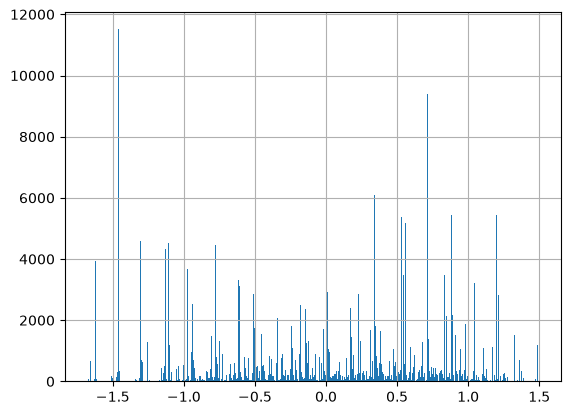

In [43]:
wealth_relevant_info.combined_score.hist(bins=500)

In [44]:
wealth_relevant_info["weighted_household_size"] = (
    wealth_relevant_info.hh_size * wealth_relevant_info.multiplier
)

from statsmodels.stats.weightstats import DescrStatsW

wq = DescrStatsW(
    data=wealth_relevant_info.combined_score,
    weights=wealth_relevant_info.weighted_household_size,
)
quintile_cutoffs = wq.quantile(probs=np.linspace(0, 1, 6))
quintile_cutoffs

p
0.0   -1.678890
0.2   -0.941631
0.4   -0.237848
0.6    0.341590
0.8    0.751211
1.0    1.492446
dtype: float64

In [45]:
wealth_relevant_info["wealth_quintile"] = pd.cut(
    wealth_relevant_info.combined_score,
    quintile_cutoffs,
    labels=[1, 2, 3, 4, 5],
    include_lowest=True,
)
wealth_relevant_info["wealth_quintile"]

0         5
1         5
2         4
3         5
4         4
         ..
261948    1
261949    2
261950    1
261951    3
261952    1
Name: wealth_quintile, Length: 261953, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

In [46]:
assert wealth_relevant_info.wealth_quintile.notnull().all()

In [47]:
wealth_relevant_info.groupby(
    "wealth_quintile", observed=True
).multiplier.sum() / wealth_relevant_info.multiplier.sum()

wealth_quintile
1    0.214717
2    0.205948
3    0.212930
4    0.176727
5    0.189679
Name: multiplier, dtype: float64

In [48]:
for column in wealth_predictors:
    print(column)
    print(
        wealth_relevant_info.groupby(
            ["wealth_quintile", column], observed=True
        ).multiplier.sum()
        / wealth_relevant_info.groupby("wealth_quintile").multiplier.sum()
    )

land_ownership
wealth_quintile  land_ownership
1                0.0               0.072424
                 1.0               0.927576
2                0.0               0.110031
                 1.0               0.889969
3                0.0               0.080117
                 1.0               0.919883
4                0.0               0.057157
                 1.0               0.942843
5                0.0               0.030501
                 1.0               0.969499
Name: multiplier, dtype: float64
has_dwelling
wealth_quintile  has_dwelling
1                0.0             0.019929
                 1.0             0.980071
2                0.0             0.010203
                 1.0             0.989797
3                0.0             0.001794
                 1.0             0.998206
4                0.0             0.000574
                 1.0             0.999426
5                0.0             0.000409
                 1.0             0.999591
Name: multiplier,

wealth_quintile  cooking_energy_source_dung
1                0                             0.982266
                 1                             0.017734
2                0                             0.964849
                 1                             0.035151
3                0                             0.986743
                 1                             0.013257
4                0                             0.994396
                 1                             0.005604
5                0                             0.999640
                 1                             0.000360
Name: multiplier, dtype: float64
cooking_energy_source_electricity
wealth_quintile  cooking_energy_source_electricity
1                0                                    0.999789
                 1                                    0.000211
2                0                                    0.996735
                 1                                    0.003265
3                0        

In [49]:
# Whoa, owning land or a house is uncorrelated?!
india_dhs = pd.read_stata(
    "/snfs1/DATA/DHS_PROG_DHS/IND/2015_2016/IND_DHS7_2015_2016_HH_IAHR74FL_Y2018M12D06.DTA",
    columns=["hv005", "hv270", "sh46"],
).rename(columns={"hv005": "weight", "hv270": "wealth_quintile", "sh46": "owns_house"})

In [50]:
india_dhs.groupby(
    ["wealth_quintile", "owns_house"], observed=True
).weight.sum() / india_dhs.groupby("wealth_quintile").weight.sum()

wealth_quintile  owns_house
poorest          no            0.174830
                 yes           0.825170
poorer           no            0.179612
                 yes           0.820388
middle           no            0.213271
                 yes           0.786729
richer           no            0.248677
                 yes           0.751323
richest          no            0.191180
                 yes           0.808820
Name: weight, dtype: float64

In [51]:
# Bizarre. Even in DHS it's basically uncorrelated, although in HCES it seems to be reversed.

In [52]:
households["wealth_quintile"] = wealth_relevant_info["wealth_quintile"]

In [53]:
assert households.wealth_quintile.notnull().all()

## Household rice consumption

Item codes for 'Rice' include: 101, 102, and 061. See Section 5.1 of the above documentation for more context.

- Item code 101 signifies rice procured through PDS, using ration card.
- Item code 061 signifies rice procured through PDS, free of charge.
- Item code 102 signifies rice procured/consumed from other sources. (NOTE: Presumably this is unfortified rice.)

Units: kg/30 days.

In [54]:
consumption = read_hces_level(
    5,
    names=[
        "q_num",
        "level",
        "item_code",
        "consumption_amt_home_produce",
        "consumption_value_home_produce",
        "total_consumption_amt",
        "total_consumption_value",
        "source",
        "multiplier",
    ],
    row_filter=lambda df: df[df.item_code.isin([61, 101, 102])],
)
consumption


,common_id,q_num,level,item_code,consumption_amt_home_produce,consumption_value_home_produce,total_consumption_amt,total_consumption_value,source,multiplier
0,HCES2024466671010120613012 201103 201,F,5,101,NaN,NaN,15.0,225.0,1.0,16669
1,HCES2024466671010120613012 201103 301,F,5,102,NaN,NaN,10.0,750.0,1.0,24840
2,HCES2024466671010120613012 201103 302,F,5,61,NaN,NaN,15.0,NaN,1.0,24840
3,HCES2024466671010120613012 201103 303,F,5,101,NaN,NaN,15.0,225.0,1.0,24840
4,HCES2024466671010120613012 201103 304,F,5,102,NaN,NaN,10.0,600.0,1.0,24840
...,...,...,...,...,...,...,...,...,...,...
384040,HCES20242245123737101120110201201 308,F,5,102,NaN,NaN,15.0,550.0,1.0,1325
384041,HCES20242245123737101120110201201 309,F,5,61,NaN,NaN,5.0,NaN,1.0,1325
384042,HCES20242245123737101120110201201 309,F,5,102,NaN,NaN,8.0,280.0,1.0,1325
384043,HCES20242245123737101120110201201 310,F,5,61,NaN,NaN,10.0,NaN,1.0,1325


In [55]:
consumption["item_code"] = consumption.item_code.map(
    {
        61: "pds free rice",
        101: "pds paid rice",
        102: "other rice",
    }
)
consumption["is_pds"] = consumption.item_code.isin(["pds free rice", "pds paid rice"])

In [56]:
consumption["source"] = consumption.source.map(
    {
        1: "only purchase",
        2: "only home-grown",
        3: "both purchase and home-grown",
        4: "only free collection",
        5: "only exchange",
        6: "only gifts",
        9: "other",
    }
)

In [57]:
consumption["total_consumption_amt"] = consumption.total_consumption_amt.astype(float)
consumption["consumption_amt_home_produce"] = (
    consumption.consumption_amt_home_produce.astype(float)
)

In [58]:
# I assume for these high-missingness columns, null means 0
consumption.isnull().mean()

common_id                         0.000000
q_num                             0.000000
level                             0.000000
item_code                         0.000000
consumption_amt_home_produce      0.923267
consumption_value_home_produce    0.923275
total_consumption_amt             0.000000
total_consumption_value           0.328889
source                            0.039928
multiplier                        0.000000
is_pds                            0.000000
dtype: float64

In [59]:
(consumption == 0).mean()

common_id                         0.000000
q_num                             0.000000
level                             0.000000
item_code                         0.000000
consumption_amt_home_produce      0.000018
consumption_value_home_produce    0.000010
total_consumption_amt             0.000000
total_consumption_value           0.039948
source                            0.000000
multiplier                        0.000000
is_pds                            0.562819
dtype: float64

In [60]:
consumption = consumption.fillna(0)

In [61]:
consumption["pds_rice"] = np.where(
    consumption.is_pds,
    consumption.total_consumption_amt,
    0.0,
)

In [62]:
consumption["non_pds_rice_purchased"] = np.where(
    consumption.is_pds,
    0.0,
    np.where(
        consumption.source.isin(["only purchase", "both purchase and home-grown"]),
        consumption.total_consumption_amt - consumption.consumption_amt_home_produce,
        0.0,
    ),
)

In [63]:
consumption["non_pds_rice_non_purchased"] = (
    consumption.total_consumption_amt
    - consumption.pds_rice
    - consumption.non_pds_rice_purchased
)

In [64]:
consumption = consumption.groupby("common_id")[
    ["pds_rice", "non_pds_rice_purchased", "non_pds_rice_non_purchased"]
].sum()
consumption

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased
common_id,,,
HCES20242230023434102320110133231 101,0.0,25.0,0.0
HCES20242230023434102320110133231 201,0.0,23.0,0.0
HCES20242230023434102320110133231 202,0.0,12.0,0.0
HCES20242230023434102320110133231 203,0.0,12.0,0.0
HCES20242230023434102320110133231 204,0.0,15.0,0.0
...,...,...,...
HCES2024499991181840623135 118213 314,30.0,20.0,10.0
HCES2024499991181840623135 118213 315,20.0,0.0,20.0
HCES2024499991181840623135 118213 316,30.0,15.0,20.0


In [65]:
consumption["rice"] = consumption.sum(axis=1)
consumption["proportion_non_pds_purchased"] = (
    consumption.non_pds_rice_purchased / (consumption.rice - consumption.pds_rice)
).clip(0, 1)
consumption

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased
common_id,,,,,
HCES20242230023434102320110133231 101,0.0,25.0,0.0,25.0,1.000000
HCES20242230023434102320110133231 201,0.0,23.0,0.0,23.0,1.000000
HCES20242230023434102320110133231 202,0.0,12.0,0.0,12.0,1.000000
HCES20242230023434102320110133231 203,0.0,12.0,0.0,12.0,1.000000
HCES20242230023434102320110133231 204,0.0,15.0,0.0,15.0,1.000000
...,...,...,...,...,...
HCES2024499991181840623135 118213 314,30.0,20.0,10.0,60.0,0.666667
HCES2024499991181840623135 118213 315,20.0,0.0,20.0,40.0,0.000000
HCES2024499991181840623135 118213 316,30.0,15.0,20.0,65.0,0.428571


In [66]:
len(consumption) / len(households)

0.9675552484606017

In [67]:
(households.merge(consumption, on="common_id", how="left").rice > 0).mean()

0.9675552484606017

In [68]:
consumption = consumption.reindex(households.common_id).fillna(0).reset_index()
consumption

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased
0,HCES2024466671010120613012 201103 201,15.0,0.0,0.0,15.0,0.0
1,HCES2024466671010120613012 201103 301,0.0,10.0,0.0,10.0,1.0
2,HCES2024466671010120613012 201103 302,15.0,0.0,0.0,15.0,0.0
3,HCES2024466671010120613012 201103 303,15.0,0.0,0.0,15.0,0.0
4,HCES2024466671010120613012 201103 304,0.0,10.0,0.0,10.0,1.0
...,...,...,...,...,...,...
261948,HCES2024432771101011923356 2101116 314,0.0,25.0,0.0,25.0,1.0
261949,HCES2024432771101011923356 2101116 315,20.0,12.0,0.0,32.0,1.0
261950,HCES2024432771101011923356 2101116 316,16.0,14.0,0.0,30.0,1.0
261951,HCES2024432771101011923356 2101116 317,20.0,8.0,0.0,28.0,1.0


In [69]:
(households.merge(consumption, on="common_id", how="left").rice > 0).mean()

0.9675552484606017

## Individual rice consumption

We distribute the rice to the individuals according to the number of meals they have eaten at home.
We assume that children eating school lunches are getting fortified rice, as the scale-up has also
happened through that program.
Otherwise, we assume that meals eaten away from the home use rice and fortified rice at the same rate
as meals at home.

In [70]:
# Level 2 was read once in the wealth section (for the internet indicator); reuse it.
household_members = household_members_raw[
    ["common_id", "gender", "age_years", "multiplier"]
    + [c for c in household_members_raw.columns if "meals" in c]
]
household_members


,common_id,gender,age_years,multiplier,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days
0,HCES2024403761323210523021 132102 201,1,58,153083,3.0,NaN,NaN,3.0,NaN,87.0
1,HCES2024403761323210523021 132102 201,2,47,153083,3.0,NaN,NaN,2.0,NaN,88.0
2,HCES2024403761323210523021 132102 201,1,17,153083,3.0,NaN,NaN,2.0,NaN,88.0
3,HCES2024403761323210523021 132102 201,2,26,153083,3.0,NaN,NaN,NaN,NaN,90.0
4,HCES2024403761323210523021 132102 201,1,45,153083,3.0,NaN,NaN,6.0,NaN,84.0
...,...,...,...,...,...,...,...,...,...,...
1107216,HCES2024432771101011923356 2101116 317,1,20,157235,2.0,NaN,NaN,NaN,8.0,52.0
1107217,HCES2024432771101011923356 2101116 317,1,18,157235,3.0,NaN,NaN,NaN,NaN,90.0
1107218,HCES2024432771101011923356 2101116 317,1,16,157235,3.0,NaN,NaN,NaN,NaN,90.0
1107219,HCES2024432771101011923356 2101116 318,1,25,157235,2.0,NaN,NaN,NaN,NaN,60.0


In [71]:
# My interpretation: null basically is equivalent to 0 for these high-missingness columns...
household_members.filter(like="meals").isnull().mean()

usual_daily_meals                         0.002348
meals_from_school_balwadi_last_30_days    0.684347
meals_from_employer_last_30_days          0.726588
meals_others_last_30_days                 0.641105
meals_paid_last_30_days                   0.662048
meals_at_home_last_30_days                0.006936
dtype: float64

In [72]:
# ... even though there are actual zeros!
(household_members.filter(like="meals") == 0).mean()

usual_daily_meals                         0.007832
meals_from_school_balwadi_last_30_days    0.252655
meals_from_employer_last_30_days          0.267508
meals_others_last_30_days                 0.232350
meals_paid_last_30_days                   0.249869
meals_at_home_last_30_days                0.008795
dtype: float64

In [73]:
for col in [
    "meals_from_school_balwadi_last_30_days",
    "meals_from_employer_last_30_days",
    "meals_others_last_30_days",
    "meals_paid_last_30_days",
]:
    household_members[col] = household_members[col].fillna(0)

/tmp/ipykernel_2899154/733861462.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  household_members[col] = household_members[col].fillna(0)


In [74]:
household_members.isnull().mean()

common_id                                 0.000000
gender                                    0.000000
age_years                                 0.000000
multiplier                                0.000000
usual_daily_meals                         0.002348
meals_from_school_balwadi_last_30_days    0.000000
meals_from_employer_last_30_days          0.000000
meals_others_last_30_days                 0.000000
meals_paid_last_30_days                   0.000000
meals_at_home_last_30_days                0.006936
dtype: float64

In [75]:
# Complete-case analysis
household_members = household_members.dropna(how="any").copy()
household_members

,common_id,gender,age_years,multiplier,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days
0,HCES2024403761323210523021 132102 201,1,58,153083,3.0,0.0,0.0,3.0,0.0,87.0
1,HCES2024403761323210523021 132102 201,2,47,153083,3.0,0.0,0.0,2.0,0.0,88.0
2,HCES2024403761323210523021 132102 201,1,17,153083,3.0,0.0,0.0,2.0,0.0,88.0
3,HCES2024403761323210523021 132102 201,2,26,153083,3.0,0.0,0.0,0.0,0.0,90.0
4,HCES2024403761323210523021 132102 201,1,45,153083,3.0,0.0,0.0,6.0,0.0,84.0
...,...,...,...,...,...,...,...,...,...,...
1107216,HCES2024432771101011923356 2101116 317,1,20,157235,2.0,0.0,0.0,0.0,8.0,52.0
1107217,HCES2024432771101011923356 2101116 317,1,18,157235,3.0,0.0,0.0,0.0,0.0,90.0
1107218,HCES2024432771101011923356 2101116 317,1,16,157235,3.0,0.0,0.0,0.0,0.0,90.0
1107219,HCES2024432771101011923356 2101116 318,1,25,157235,2.0,0.0,0.0,0.0,0.0,60.0


In [76]:
household_members["gender"] = household_members.gender.map(
    {
        1: "Male",
        2: "Female",
        3: "Transgender",
    }
)

In [77]:
household_members = household_members.merge(
    households[["common_id", "wealth_quintile"]],
    on="common_id",
    validate="m:1",
    how="left",
)

In [78]:
assert household_members.wealth_quintile.notnull().all()

In [79]:
household_members["meals"] = (
    household_members.meals_at_home_last_30_days.fillna(0)
    + household_members.meals_from_employer_last_30_days.fillna(0)
    + household_members.meals_from_school_balwadi_last_30_days.fillna(0)
    + household_members.meals_from_employer_last_30_days.fillna(0)
    + household_members.meals_paid_last_30_days.fillna(0)
    + household_members.meals_others_last_30_days.fillna(0)
)

<Axes: xlabel='usual_daily_meals', ylabel='meals'>

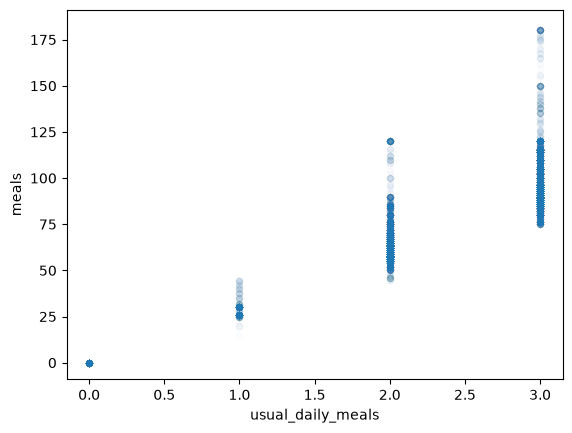

In [80]:
household_members.plot(kind="scatter", x="usual_daily_meals", y="meals", alpha=0.01)

In [81]:
household_meals = household_members.groupby(
    "common_id"
).meals_at_home_last_30_days.sum()
household_meals

common_id
HCES20242230023434102320110133231  101    347.0
HCES20242230023434102320110133231  201    350.0
HCES20242230023434102320110133231  202    180.0
HCES20242230023434102320110133231  203    174.0
HCES20242230023434102320110133231  204    175.0
                                          ...  
HCES2024499991181840623135 118213  314    360.0
HCES2024499991181840623135 118213  315    338.0
HCES2024499991181840623135 118213  316    420.0
HCES2024499991181840623135 118213  317    968.0
HCES2024499991181840623135 118213  318    425.0
Name: meals_at_home_last_30_days, Length: 258537, dtype: float64

In [82]:
consumption = consumption.merge(
    household_meals, on="common_id", validate="1:1", how="left"
)
consumption

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased,meals_at_home_last_30_days
0,HCES2024466671010120613012 201103 201,15.0,0.0,0.0,15.0,0.0,439.0
1,HCES2024466671010120613012 201103 301,0.0,10.0,0.0,10.0,1.0,345.0
2,HCES2024466671010120613012 201103 302,15.0,0.0,0.0,15.0,0.0,442.0
3,HCES2024466671010120613012 201103 303,15.0,0.0,0.0,15.0,0.0,442.0
4,HCES2024466671010120613012 201103 304,0.0,10.0,0.0,10.0,1.0,261.0
...,...,...,...,...,...,...,...
261948,HCES2024432771101011923356 2101116 314,0.0,25.0,0.0,25.0,1.0,300.0
261949,HCES2024432771101011923356 2101116 315,20.0,12.0,0.0,32.0,1.0,290.0
261950,HCES2024432771101011923356 2101116 316,16.0,14.0,0.0,30.0,1.0,285.0
261951,HCES2024432771101011923356 2101116 317,20.0,8.0,0.0,28.0,1.0,352.0


In [83]:
consumption.isnull().mean()

common_id                       0.000000
pds_rice                        0.000000
non_pds_rice_purchased          0.000000
non_pds_rice_non_purchased      0.000000
rice                            0.000000
proportion_non_pds_purchased    0.000000
meals_at_home_last_30_days      0.013041
dtype: float64

In [84]:
consumption = consumption.dropna(how="any").copy()
consumption

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased,meals_at_home_last_30_days
0,HCES2024466671010120613012 201103 201,15.0,0.0,0.0,15.0,0.0,439.0
1,HCES2024466671010120613012 201103 301,0.0,10.0,0.0,10.0,1.0,345.0
2,HCES2024466671010120613012 201103 302,15.0,0.0,0.0,15.0,0.0,442.0
3,HCES2024466671010120613012 201103 303,15.0,0.0,0.0,15.0,0.0,442.0
4,HCES2024466671010120613012 201103 304,0.0,10.0,0.0,10.0,1.0,261.0
...,...,...,...,...,...,...,...
261948,HCES2024432771101011923356 2101116 314,0.0,25.0,0.0,25.0,1.0,300.0
261949,HCES2024432771101011923356 2101116 315,20.0,12.0,0.0,32.0,1.0,290.0
261950,HCES2024432771101011923356 2101116 316,16.0,14.0,0.0,30.0,1.0,285.0
261951,HCES2024432771101011923356 2101116 317,20.0,8.0,0.0,28.0,1.0,352.0


In [85]:
consumption["rice_per_meal_kg"] = np.where(
    consumption.rice == 0,
    0.0,
    consumption.rice / consumption.meals_at_home_last_30_days,
)

In [86]:
# In a small number of cases, rice consumption is reported despite very few or no meals at home
impossible_rice_consumption = (consumption.rice > 0) & (
    consumption.meals_at_home_last_30_days == 0
)
consumption[impossible_rice_consumption]

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased,meals_at_home_last_30_days,rice_per_meal_kg
76465,HCES2024492771191941223187 219124 301,5.0,0.00,0.0,5.00,0.0,0.0,inf
129620,HCES20244821412828101230110228221 315,35.0,0.00,0.0,35.00,0.0,0.0,inf
130698,HCES2024488861292932821012 229101 310,0.2,0.00,0.0,0.20,0.0,0.0,inf
132657,HCES2024480091292931923057 129122 313,3.0,0.00,0.0,3.00,0.0,0.0,inf
153058,HCES2024417611363610523095 136126 302,0.0,8.00,0.0,8.00,1.0,0.0,inf
153062,HCES2024417611363610523095 136126 306,6.0,3.00,0.0,9.00,1.0,0.0,inf
154395,HCES2024266722010112112029 101101 302,0.0,5.00,0.0,5.00,1.0,0.0,inf
161598,HCES2024269032060610322026 206111 304,0.0,1.00,0.0,1.00,1.0,0.0,inf
161601,HCES2024269032060610322026 206111 307,0.0,1.30,0.0,1.30,1.0,0.0,inf
169789,HCES2024276642080820722031 208211 302,0.0,0.50,0.0,0.50,1.0,0.0,inf


In [87]:
# This must be wrong somehow, so we clip it
consumption["rice_per_meal_kg"] = consumption["rice_per_meal_kg"].clip(
    upper=np.percentile(consumption.rice_per_meal_kg, 95)
)

<Axes: >

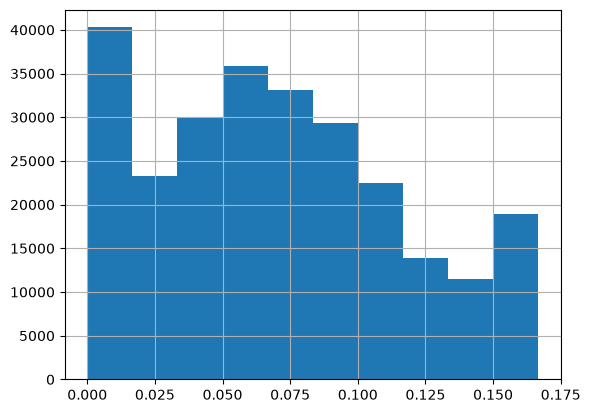

In [88]:
consumption[consumption.rice_per_meal_kg.notnull()].sort_values("rice_per_meal_kg")
consumption.rice_per_meal_kg.hist()

<Axes: >

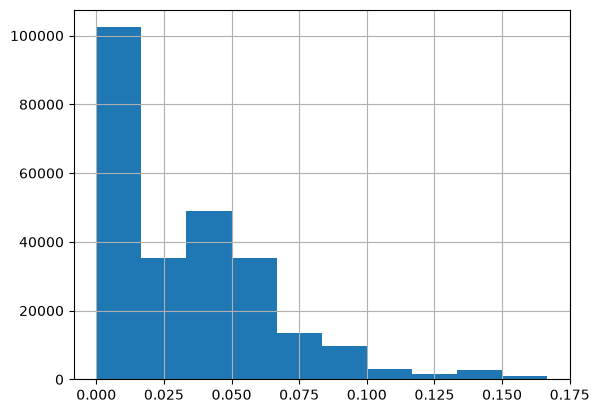

In [89]:
consumption["pds_rice_per_meal_kg"] = consumption.rice_per_meal_kg * (
    consumption.pds_rice / consumption.rice
)
consumption.pds_rice_per_meal_kg.hist()

In [90]:
household_members = household_members.merge(
    consumption.reset_index()[
        [
            "common_id",
            "rice_per_meal_kg",
            "pds_rice_per_meal_kg",
            "proportion_non_pds_purchased",
        ]
    ],
    on="common_id",
    how="left",
    validate="m:1",
)
household_members

,common_id,gender,age_years,multiplier,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days,wealth_quintile,meals,rice_per_meal_kg,pds_rice_per_meal_kg,proportion_non_pds_purchased
0,HCES2024403761323210523021 132102 201,Male,58,153083,3.0,0.0,0.0,3.0,0.0,87.0,5,90.0,0.059896,0.007812,1.0
1,HCES2024403761323210523021 132102 201,Female,47,153083,3.0,0.0,0.0,2.0,0.0,88.0,5,90.0,0.059896,0.007812,1.0
2,HCES2024403761323210523021 132102 201,Male,17,153083,3.0,0.0,0.0,2.0,0.0,88.0,5,90.0,0.059896,0.007812,1.0
3,HCES2024403761323210523021 132102 201,Female,26,153083,3.0,0.0,0.0,0.0,0.0,90.0,5,90.0,0.059896,0.007812,1.0
4,HCES2024403761323210523021 132102 201,Male,45,153083,3.0,0.0,0.0,6.0,0.0,84.0,5,90.0,0.059896,0.007812,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099472,HCES2024432771101011923356 2101116 317,Male,20,157235,2.0,0.0,0.0,0.0,8.0,52.0,3,60.0,0.079545,0.056818,1.0
1099473,HCES2024432771101011923356 2101116 317,Male,18,157235,3.0,0.0,0.0,0.0,0.0,90.0,3,90.0,0.079545,0.056818,1.0
1099474,HCES2024432771101011923356 2101116 317,Male,16,157235,3.0,0.0,0.0,0.0,0.0,90.0,3,90.0,0.079545,0.056818,1.0
1099475,HCES2024432771101011923356 2101116 318,Male,25,157235,2.0,0.0,0.0,0.0,0.0,60.0,1,60.0,0.125000,0.066667,1.0


In [91]:
household_members.isnull().mean()

common_id                                 0.000000
gender                                    0.000000
age_years                                 0.000000
multiplier                                0.000000
usual_daily_meals                         0.000000
meals_from_school_balwadi_last_30_days    0.000000
meals_from_employer_last_30_days          0.000000
meals_others_last_30_days                 0.000000
meals_paid_last_30_days                   0.000000
meals_at_home_last_30_days                0.000000
wealth_quintile                           0.000000
meals                                     0.000000
rice_per_meal_kg                          0.000000
pds_rice_per_meal_kg                      0.013154
proportion_non_pds_purchased              0.000000
dtype: float64

In [92]:
household_members["government_meals_away_from_home"] = (
    household_members.meals_from_school_balwadi_last_30_days
)
household_members["non_government_meals_away_from_home"] = (
    household_members.meals
    - household_members.meals_at_home_last_30_days
    - household_members.government_meals_away_from_home
)
household_members["rice"] = household_members.meals * household_members.rice_per_meal_kg
household_members["government_rice"] = (
    household_members.meals_at_home_last_30_days
    * household_members.pds_rice_per_meal_kg
    + (
        household_members.government_meals_away_from_home
        * household_members.rice_per_meal_kg
    )
    + (
        household_members.non_government_meals_away_from_home
        * household_members.pds_rice_per_meal_kg
    )  # Assume same as at-home meals
)
household_members["proportion_government"] = (
    household_members.government_rice / household_members.rice
).clip(0, 1)
# NOTE: For now, we say only government rice is fortifiable!
household_members["proportion_fortifiable"] = household_members["proportion_government"]
# (
#     # It's assumed that all non-government rice you consume is fortifiable if it was purchased; we use your household's rate of
#     # purchasing vs growing for non-PDS rice for this.
#     # All government rice is fortifiable.
#     (
#         household_members.government_rice
#         + (
#             household_members.proportion_non_pds_purchased
#             * (household_members.rice - household_members.government_rice)
#         )
#     )
#     / household_members.rice
# )

In [93]:
household_members.isnull().mean()

common_id                                 0.000000
gender                                    0.000000
age_years                                 0.000000
multiplier                                0.000000
usual_daily_meals                         0.000000
meals_from_school_balwadi_last_30_days    0.000000
meals_from_employer_last_30_days          0.000000
meals_others_last_30_days                 0.000000
meals_paid_last_30_days                   0.000000
meals_at_home_last_30_days                0.000000
wealth_quintile                           0.000000
meals                                     0.000000
rice_per_meal_kg                          0.000000
pds_rice_per_meal_kg                      0.013154
proportion_non_pds_purchased              0.000000
government_meals_away_from_home           0.000000
non_government_meals_away_from_home       0.000000
rice                                      0.000000
government_rice                           0.013154
proportion_government          

In [94]:
# Convert kg/30 days to g/day
household_members["rice_g_per_day"] = household_members.rice / 30 * 1_000

In [95]:
household_members["sex"] = household_members.gender.replace(
    {"Transgender": np.nan}
)  # We don't know the sex of transgender people in the survey :(
age_bin_edges = [0, 5, 15, 30, 50, 125]
age_group = pd.IntervalIndex(
    pd.cut(household_members.age_years, age_bin_edges, right=False, include_lowest=True)
)
household_members["age_start"] = age_group.left
household_members["age_end"] = age_group.right

In [96]:
# https://stackoverflow.com/a/2415343/ with some tweaks
def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    is_nan = np.isnan(values)
    values = values[~is_nan]
    # The tab exports parse the multiplier as int64, and weights.sum()**2 overflows
    # int64 in the effective-sample-size line; promote to float.
    weights = weights[~is_nan].astype(float)
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values - average) ** 2, weights=weights)
    return pd.Series(
        {
            "mean": average,
            "sd": np.sqrt(variance),
            # https://ngreifer.github.io/WeightIt/reference/ESS.html
            "effective_sample_size": (weights.sum() ** 2) / (weights**2).sum(),
        }
    )

In [97]:
results_dir = "../results/"

In [98]:
import pathlib


def save_data(series, name):
    path = f"{results_dir}/{name}/india.csv"
    pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
    (
        series.rename("value")
        .reset_index()
        .assign(vehicle_name="rice")
        .to_csv(path, index=False)
    )


def save_for_each_fortificant(series, name):
    save_data(series, f"iron/{name}")
    save_data(series, f"folate/{name}")

In [99]:
weighted_avg_and_std(
    household_members.rice_g_per_day > 0, weights=household_members.multiplier
)

mean                          0.978072
sd                            0.146448
effective_sample_size    757012.583701
dtype: float64

In [100]:
(
    household_members.groupby("wealth_quintile")
    .apply(
        lambda df: weighted_avg_and_std(df.rice_g_per_day > 0, weights=df.multiplier)
    )
    .sort_index()
)

,mean,sd,effective_sample_size
wealth_quintile,,,
1,0.972535,0.163435,161777.795702
2,0.969541,0.171846,154018.083482
3,0.982111,0.132547,164731.050610
4,0.985456,0.119720,138151.620870
5,0.981044,0.136370,139952.971220


In [101]:
# NOTE: We do not have pregnancy status in this survey, so we assume it has no effect on consumption!
any_consumption = (
    household_members.groupby(
        ["sex", "age_start", "age_end", "wealth_quintile"], observed=True
    )
    .apply(
        lambda df: weighted_avg_and_std(
            np.where(df.rice_g_per_day.notnull(), df.rice_g_per_day > 0, np.nan),
            weights=df.multiplier,
        )
    )
    .sort_index()
)
any_consumption

mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0         5       1                0.890088  0.312780   
                         2                0.875116  0.330588   
                         3                0.873100  0.332861   
                         4                0.884775  0.319293   
                         5                0.865564  0.341120   
       5         15      1                0.961146  0.193248   
                         2                0.980478  0.138350   
                         3                0.989830  0.100331   
                         4                0.992594  0.085739   
                         5                0.988565  0.106320   
       15        30      1                0.976640  0.151044   
                         2                0.970350  0.169620   
                         3                0.988181  0.108069   
                         4                0.991723  0.090603   
                         5                0.988301  0.107527   
       30        50      1                0.990253  0.098243   
                         2                0.987107  0.112813   
                         3                0.991045  0.094204   
                         4                0.992216  0.087884   
                         5                0.988881  0.104861   
       50        125     1                0.981591  0.134424   
                         2                0.981743  0.133879   
                         3                0.989552  0.101680   
                         4                0.991200  0.093395   
                         5                0.986714  0.114495   
Male   0         5       1                0.893595  0.308356   
                         2                0.873293  0.332644   
                         3                0.876243  0.329304   
                         4                0.882421  0.322109   
                         5                0.873005  0.332968   
       5         15      1                0.973296  0.161218   
                         2                0.982061  0.132729   
                         3                0.990476  0.097123   
                         4                0.992162  0.088185   
                         5                0.986884  0.113772   
       15        30      1                0.976932  0.150121   
                         2                0.959437  0.197275   
                         3                0.987114  0.112782   
                         4                0.991197  0.093408   
                         5                0.988108  0.108402   
       30        50      1                0.989128  0.103702   
                         2                0.980841  0.137083   
                         3                0.990137  0.098820   
                         4                0.992291  0.087460   
                         5                0.987843  0.109586   
       50        125     1                0.983608  0.126976   
                         2                0.981501  0.134747   
                         3                0.989091  0.103873   
                         4                0.991373  0.092480   
                         5                0.986208  0.116628   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                          6268.530724  
                         2                          5497.291178  
                         3                          4966.636820  
                         4                          3801.162571  
                         5                          3789.443714  
       5         15      1                         16295.633358  
                         2                         14029.643687  
                         3                         13023.610898  
                         4                         10253.

In [102]:
save_data(any_consumption["mean"], "rice/vehicle_consumption/any")

In [103]:
weighted_avg_and_std(
    household_members.rice_g_per_day, weights=household_members.multiplier
)

mean                        159.188301
sd                          112.261250
effective_sample_size    757012.583701
dtype: float64

In [104]:
(
    household_members.groupby("wealth_quintile")
    .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day, weights=df.multiplier))
    .sort_index()
)

,mean,sd,effective_sample_size
wealth_quintile,,,
1,193.193414,119.693717,161777.795702
2,160.882560,115.676702,154018.083482
3,161.818410,104.640316,164731.050610
4,160.840115,105.790889,138151.620870
5,118.640131,101.456451,139952.971220


In [105]:
consumption_amount = (
    household_members.groupby(
        ["sex", "age_start", "age_end", "wealth_quintile"], observed=True
    )
    .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day, weights=df.multiplier))
    .sort_index()
)
consumption_amount

mean          sd  \
sex    age_start age_end wealth_quintile                           
Female 0         5       1                163.930276  116.768667   
                         2                134.770586  112.907306   
                         3                127.861867  100.712808   
                         4                131.586203  100.895924   
                         5                 97.156436   94.634835   
       5         15      1                188.161227  118.095656   
                         2                161.624411  111.686526   
                         3                162.037188   99.991013   
                         4                160.098785  103.282688   
                         5                121.701138  101.343495   
       15        30      1                190.906339  116.890824   
                         2                154.975414  113.884123   
                         3                154.945647  101.786032   
                         4                157.919480  103.480650   
                         5                117.733204  101.524225   
       30        50      1                199.812958  119.689798   
                         2                166.211619  115.642069   
                         3                167.842769  105.301299   
                         4                166.715449  107.307830   
                         5                121.557051  103.106286   
       50        125     1                199.445477  123.259541   
                         2                171.468268  118.033220   
                         3                175.468434  109.933589   
                         4                164.029667  104.648636   
                         5                121.437196   99.797132   
Male   0         5       1                164.297660  117.952090   
                         2                135.227609  110.805222   
                         3                129.606222   98.218639   
                         4                130.593728  101.533758   
                         5                 97.039424   92.544216   
       5         15      1                193.369603  117.658253   
                         2                162.598215  111.228898   
                         3                161.446470   99.052025   
                         4                162.640493  104.531003   
                         5                117.640089  100.546338   
       15        30      1                195.437284  118.149492   
                         2                157.445431  117.966746   
                         3                158.890550  104.103278   
                         4                157.565024  105.522541   
                         5                118.197052  102.313697   
       30        50      1                197.584417  120.362291   
                         2                162.424090  116.859400   
                         3                161.847669  105.364894   
                         4                164.110302  108.033783   
                         5                117.891888  102.715712   
       50        125     1                201.323195  123.093882   
                         2                171.743421  117.770927   
                         3                172.558900  107.541865   
                         4                167.453465  106.588431   
                         5                123.240231  101.211259   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                          6268.530724  
                         2                          5497.291178  
                         3                          4966.636820  
                         4                          3801.162571  
                         5                          3789.443714  
       5         15      1                       

In [106]:
save_data(consumption_amount["mean"], "rice/vehicle_consumption/amount/mean")
save_data(consumption_amount["sd"], "rice/vehicle_consumption/amount/sd")

In [107]:
# NOTE: Government rice fortification scale-up is still in progress.
# According to this dashboard (https://impds.nic.in/sale/stateUnautmated?month=1&year=2024) it is
# around 70% in 2024. We say that it can't get above 80% due to compliance issues.
# We apply maximum individual heterogeneity, meaning that the people who are missed
# due to compliance are *completely* missed.
GOVERNMENT_BASELINE_COVERAGE = 0.8

In [108]:
weighted_avg_and_std(
    GOVERNMENT_BASELINE_COVERAGE * household_members.proportion_government,
    weights=household_members.multiplier,
)

mean                          0.355512
sd                            0.286164
effective_sample_size    744956.328591
dtype: float64

In [109]:
(
    household_members.groupby("wealth_quintile")
    .apply(
        lambda df: weighted_avg_and_std(
            GOVERNMENT_BASELINE_COVERAGE * df.proportion_government,
            weights=df.multiplier,
        )
    )
    .sort_index()
)

,mean,sd,effective_sample_size
wealth_quintile,,,
1,0.431122,0.247711,158764.318417
2,0.415996,0.278857,153118.684338
3,0.385614,0.281922,161568.509488
4,0.352795,0.280100,136190.628889
5,0.191118,0.273888,137288.907189


In [110]:
any_fortification = (
    household_members.groupby(
        ["sex", "age_start", "age_end", "wealth_quintile"], observed=True
    )
    .apply(
        lambda df: weighted_avg_and_std(
            np.where(
                df.proportion_government.notnull(),
                GOVERNMENT_BASELINE_COVERAGE * (df.proportion_government > 0),
                np.nan,
            ),
            weights=df.multiplier,
        )
    )
    .sort_index()
)
any_fortification

mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0         5       1                0.624237  0.331237   
                         2                0.584066  0.355133   
                         3                0.554623  0.368906   
                         4                0.559809  0.366689   
                         5                0.346473  0.396402   
       5         15      1                0.733094  0.221468   
                         2                0.688794  0.276763   
                         3                0.646130  0.315309   
                         4                0.617076  0.335973   
                         5                0.368363  0.398747   
       15        30      1                0.664081  0.300435   
                         2                0.608319  0.341472   
                         3                0.577004  0.358705   
                         4                0.566449  0.363724   
                         5                0.338410  0.395230   
       30        50      1                0.693355  0.271924   
                         2                0.637818  0.321625   
                         3                0.602517  0.344945   
                         4                0.575737  0.359328   
                         5                0.308717  0.389445   
       50        125     1                0.695844  0.269214   
                         2                0.657161  0.306379   
                         3                0.617750  0.335537   
                         4                0.562188  0.365643   
                         5                0.295784  0.386185   
Male   0         5       1                0.617531  0.335679   
                         2                0.594824  0.349347   
                         3                0.551035  0.370389   
                         4                0.557544  0.367668   
                         5                0.337117  0.395026   
       5         15      1                0.732355  0.222577   
                         2                0.680869  0.284802   
                         3                0.630031  0.327239   
                         4                0.606659  0.342480   
                         5                0.342942  0.395910   
       15        30      1                0.686303  0.279340   
                         2                0.590105  0.351938   
                         3                0.585252  0.354516   
                         4                0.576942  0.358736   
                         5                0.339994  0.395473   
       30        50      1                0.680789  0.284882   
                         2                0.603896  0.344132   
                         3                0.576450  0.358978   
                         4                0.565441  0.364183   
                         5                0.305508  0.388679   
       50        125     1                0.701781  0.262542   
                         2                0.652868  0.309932   
                         3                0.611147  0.339731   
                         4                0.565148  0.364316   
                         5                0.294468  0.385828   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                          5579.707956  
                         2                          4815.565204  
                         3                          4351.240340  
                         4                          3323.295987  
                         5                          3254.135601  
       5         15      1                         16158.282885  
                         2                         13816.353985  
                         3                         12866.406484  
                         4                         10198.

In [111]:
save_for_each_fortificant(
    any_fortification["mean"], "rice/baseline_fortification/any_coverage"
)

In [112]:
full_fortification = (
    household_members.groupby(
        ["sex", "age_start", "age_end", "wealth_quintile"], observed=True
    )
    .apply(
        lambda df: weighted_avg_and_std(
            np.where(
                df.proportion_government.notnull(),
                GOVERNMENT_BASELINE_COVERAGE * (df.proportion_government == 1),
                np.nan,
            ),
            weights=df.multiplier,
        )
    )
    .sort_index()
)
full_fortification

mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0         5       1                0.108446  0.273855   
                         2                0.139914  0.303900   
                         3                0.125927  0.291349   
                         4                0.112437  0.278043   
                         5                0.081985  0.242624   
       5         15      1                0.113265  0.278896   
                         2                0.139304  0.303377   
                         3                0.124909  0.290387   
                         4                0.112687  0.278301   
                         5                0.079338  0.239115   
       15        30      1                0.114477  0.280137   
                         2                0.150291  0.312483   
                         3                0.129093  0.294294   
                         4                0.114957  0.280626   
                         5                0.086277  0.248149   
       30        50      1                0.125319  0.290776   
                         2                0.152048  0.313878   
                         3                0.129425  0.294600   
                         4                0.108231  0.273625   
                         5                0.066877  0.221426   
       50        125     1                0.167707  0.325638   
                         2                0.169383  0.326827   
                         3                0.136681  0.301103   
                         4                0.106275  0.271525   
                         5                0.058227  0.207825   
Male   0         5       1                0.107217  0.272540   
                         2                0.139466  0.303516   
                         3                0.119432  0.285100   
                         4                0.119872  0.285532   
                         5                0.083078  0.244051   
       5         15      1                0.115401  0.281075   
                         2                0.143482  0.306918   
                         3                0.127956  0.293244   
                         4                0.112496  0.278103   
                         5                0.078466  0.237941   
       15        30      1                0.123162  0.288723   
                         2                0.150154  0.312373   
                         3                0.136533  0.300974   
                         4                0.128004  0.293289   
                         5                0.090733  0.253680   
       30        50      1                0.120623  0.286267   
                         2                0.147307  0.310074   
                         3                0.126660  0.292036   
                         4                0.106863  0.272160   
                         5                0.068847  0.224361   
       50        125     1                0.151500  0.313445   
                         2                0.155962  0.316932   
                         3                0.128066  0.293346   
                         4                0.106840  0.272135   
                         5                0.060864  0.212100   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                          5579.707956  
                         2                          4815.565204  
                         3                          4351.240340  
                         4                          3323.295987  
                         5                          3254.135601  
       5         15      1                         16158.282885  
                         2                         13816.353985  
                         3                         12866.406484  
                         4                         10198.

In [113]:
save_for_each_fortificant(
    full_fortification["mean"], "rice/baseline_fortification/full_coverage"
)

In [114]:
# Remember, we've assumed maximum heterogeneity here, so the people who are partially covered
# have *all* of their government rice fortified.
partial_fortification_amount = (
    household_members[
        (household_members.proportion_government > 0)
        & (household_members.proportion_government < 1)
    ]
    .groupby(["sex", "age_start", "age_end", "wealth_quintile"], observed=True)
    .apply(
        lambda df: weighted_avg_and_std(df.proportion_government, weights=df.multiplier)
    )
    .sort_index()
)
partial_fortification_amount

mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0         5       1                0.529705  0.181453   
                         2                0.539072  0.186601   
                         3                0.534043  0.183729   
                         4                0.504590  0.191700   
                         5                0.472097  0.202405   
       5         15      1                0.561247  0.199543   
                         2                0.559741  0.209421   
                         3                0.553740  0.204307   
                         4                0.530998  0.201165   
                         5                0.483357  0.210675   
       15        30      1                0.532870  0.172429   
                         2                0.549423  0.177741   
                         3                0.550596  0.177815   
                         4                0.520181  0.187367   
                         5                0.490980  0.199480   
       30        50      1                0.534398  0.172517   
                         2                0.550801  0.177490   
                         3                0.542354  0.178243   
                         4                0.514386  0.184556   
                         5                0.473620  0.198367   
       50        125     1                0.531055  0.172981   
                         2                0.547698  0.177823   
                         3                0.533070  0.179792   
                         4                0.510230  0.186637   
                         5                0.459087  0.196239   
Male   0         5       1                0.530903  0.183329   
                         2                0.547639  0.183337   
                         3                0.545174  0.182002   
                         4                0.511484  0.187018   
                         5                0.465119  0.204808   
       5         15      1                0.561033  0.196179   
                         2                0.567748  0.203926   
                         3                0.556904  0.202277   
                         4                0.532435  0.198982   
                         5                0.472838  0.211045   
       15        30      1                0.538102  0.172851   
                         2                0.557704  0.175642   
                         3                0.556879  0.176945   
                         4                0.530906  0.183309   
                         5                0.494980  0.198134   
       30        50      1                0.533231  0.173372   
                         2                0.549142  0.178413   
                         3                0.542087  0.180005   
                         4                0.515511  0.186005   
                         5                0.480530  0.198687   
       50        125     1                0.531509  0.172522   
                         2                0.545560  0.178760   
                         3                0.533808  0.179340   
                         4                0.511802  0.185185   
                         5                0.462283  0.197957   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                          3580.046803  
                         2                          2646.724890  
                         3                          2392.852225  
                         4                          1957.890062  
                         5                          1109.532961  
       5         15      1                         12512.956595  
                         2                          9496.025844  
                         3                          8552.808265  
                         4                          6581.

In [115]:
save_for_each_fortificant(
    partial_fortification_amount["mean"],
    "rice/baseline_fortification/partial_coverage_amount/mean",
)
save_for_each_fortificant(
    partial_fortification_amount["sd"],
    "rice/baseline_fortification/partial_coverage_amount/sd",
)

In [116]:
weighted_avg_and_std(
    household_members.proportion_government, weights=household_members.multiplier
)

mean                          0.444390
sd                            0.357705
effective_sample_size    744956.328591
dtype: float64

In [117]:
proportion_government = (
    household_members.groupby(
        ["sex", "age_start", "age_end", "wealth_quintile"], observed=True
    )
    .apply(
        lambda df: weighted_avg_and_std(df.proportion_government, weights=df.multiplier)
    )
    .sort_index()
)
proportion_government

mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0         5       1                0.477079  0.331794   
                         2                0.474180  0.361545   
                         3                0.443586  0.362712   
                         4                0.422721  0.353251   
                         5                0.258561  0.350509   
       5         15      1                0.576428  0.290204   
                         2                0.558595  0.327759   
                         3                0.516913  0.340455   
                         4                0.475646  0.343374   
                         5                0.273801  0.353056   
       15        30      1                0.509181  0.315171   
                         2                0.502428  0.355452   
                         3                0.469639  0.358108   
                         4                0.437268  0.353577   
                         5                0.262587  0.356946   
       30        50      1                0.536096  0.305218   
                         2                0.524513  0.343936   
                         3                0.482510  0.348858   
                         4                0.435887  0.346149   
                         5                0.226772  0.334480   
       50        125     1                0.560221  0.318937   
                         2                0.545672  0.340809   
                         3                0.491405  0.345959   
                         4                0.423619  0.348718   
                         5                0.209108  0.321057   
Male   0         5       1                0.472681  0.334408   
                         2                0.486047  0.357673   
                         3                0.443414  0.361793   
                         4                0.429668  0.357054   
                         5                0.251546  0.350128   
       5         15      1                0.576915  0.289549   
                         2                0.560728  0.330751   
                         3                0.509455  0.347452   
                         4                0.469507  0.346051   
                         5                0.254401  0.349286   
       15        30      1                0.532737  0.308221   
                         2                0.494396  0.362327   
                         3                0.483019  0.358975   
                         4                0.457935  0.356834   
                         5                0.267640  0.361046   
       30        50      1                0.524151  0.310137   
                         2                0.497549  0.356168   
                         3                0.463106  0.356781   
                         4                0.429082  0.348762   
                         5                0.228212  0.337587   
       50        125     1                0.554975  0.310114   
                         2                0.533818  0.338690   
                         3                0.482423  0.344732   
                         4                0.426754  0.348052   
                         5                0.211069  0.324616   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                          5579.707956  
                         2                          4815.565204  
                         3                          4351.240340  
                         4                          3323.295987  
                         5                          3254.135601  
       5         15      1                         16158.282885  
                         2                         13816.353985  
                         3                         12866.406484  
                         4                         10198.

In [118]:
# Save locally for further scaling in the extraction notebook
proportion_government["mean"].rename("value").to_csv(
    "india_proportion_government_rice.csv"
)

In [119]:
(
    household_members.groupby("wealth_quintile")
    .apply(
        lambda df: weighted_avg_and_std(
            df.proportion_fortifiable, weights=df.multiplier
        )
    )
    .sort_index()
)

,mean,sd,effective_sample_size
wealth_quintile,,,
1,0.538902,0.309639,158764.318417
2,0.519995,0.348571,153118.684338
3,0.482018,0.352402,161568.509488
4,0.440994,0.350125,136190.628889
5,0.238898,0.342360,137288.907189


In [120]:
fortifiability_disparities = (
    household_members.groupby(
        ["sex", "age_start", "age_end", "wealth_quintile"], observed=True
    )
    .apply(
        lambda df: weighted_avg_and_std(
            df.proportion_fortifiable, weights=df.multiplier
        )
    )
    .sort_index()
)
fortifiability_disparities

mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0         5       1                0.477079  0.331794   
                         2                0.474180  0.361545   
                         3                0.443586  0.362712   
                         4                0.422721  0.353251   
                         5                0.258561  0.350509   
       5         15      1                0.576428  0.290204   
                         2                0.558595  0.327759   
                         3                0.516913  0.340455   
                         4                0.475646  0.343374   
                         5                0.273801  0.353056   
       15        30      1                0.509181  0.315171   
                         2                0.502428  0.355452   
                         3                0.469639  0.358108   
                         4                0.437268  0.353577   
                         5                0.262587  0.356946   
       30        50      1                0.536096  0.305218   
                         2                0.524513  0.343936   
                         3                0.482510  0.348858   
                         4                0.435887  0.346149   
                         5                0.226772  0.334480   
       50        125     1                0.560221  0.318937   
                         2                0.545672  0.340809   
                         3                0.491405  0.345959   
                         4                0.423619  0.348718   
                         5                0.209108  0.321057   
Male   0         5       1                0.472681  0.334408   
                         2                0.486047  0.357673   
                         3                0.443414  0.361793   
                         4                0.429668  0.357054   
                         5                0.251546  0.350128   
       5         15      1                0.576915  0.289549   
                         2                0.560728  0.330751   
                         3                0.509455  0.347452   
                         4                0.469507  0.346051   
                         5                0.254401  0.349286   
       15        30      1                0.532737  0.308221   
                         2                0.494396  0.362327   
                         3                0.483019  0.358975   
                         4                0.457935  0.356834   
                         5                0.267640  0.361046   
       30        50      1                0.524151  0.310137   
                         2                0.497549  0.356168   
                         3                0.463106  0.356781   
                         4                0.429082  0.348762   
                         5                0.228212  0.337587   
       50        125     1                0.554975  0.310114   
                         2                0.533818  0.338690   
                         3                0.482423  0.344732   
                         4                0.426754  0.348052   
                         5                0.211069  0.324616   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                          5579.707956  
                         2                          4815.565204  
                         3                          4351.240340  
                         4                          3323.295987  
                         5                          3254.135601  
       5         15      1                         16158.282885  
                         2                         13816.353985  
                         3                         12866.406484  
                         4                         10198.

In [121]:
# Save locally for further scaling in the extraction notebook
fortifiability_disparities["mean"].rename("value").to_csv(
    "india_rice_fortifiability_disparities.csv"
)